# MindBridge — Model Training
### Step 4: Training and Comparing Classical ML Models

> **Goal:** Train multiple classifiers on TF-IDF features and compare performance.

---

| Model | Type | Key Strength |
|-------|------|-------------|
| Logistic Regression | Linear | Fast, interpretable, strong baseline |
| Multinomial Naive Bayes | Probabilistic | Excellent for text, very fast |
| Random Forest | Ensemble | Handles non-linear patterns |
| Linear SVM | Linear | Best for high-dimensional text data |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.preprocessing import label_binarize

plt.rcParams['font.family'] = 'DejaVu Sans'

print("All libraries loaded.")

All libraries loaded.


In [4]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import joblib

# Load preprocessed data
X_train = sp.load_npz('models/X_train_tfidf.npz')
X_val   = sp.load_npz('models/X_val_tfidf.npz')
X_test  = sp.load_npz('models/X_test_tfidf.npz')

y_train = np.load('models/y_train.npy')
y_val   = np.load('models/y_val.npy')
y_test  = np.load('models/y_test.npy')

le         = joblib.load('models/label_encoder.pkl')
vectorizer = joblib.load('models/tfidf_vectorizer.pkl')

print("Data loaded successfully.")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")
print(f"  Classes: {list(le.classes_)}")

Data loaded successfully.
  Train : (35765, 20000)
  Val   : (7664, 20000)
  Test  : (7664, 20000)
  Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


## 1. Train All Models

In [5]:
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Linear SVM': LinearSVC(
        C=1.0, max_iter=2000,
        class_weight='balanced',
        random_state=42
    )
}

trained = {}
results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    trained[name] = model
    results[name] = {'Accuracy': acc, 'Weighted F1': f1}
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print()

print("All models trained.")



Training Logistic Regression...
  Accuracy : 0.7543
  F1 Score : 0.7538

Training Naive Bayes...
  Accuracy : 0.6951
  F1 Score : 0.6898

Training Random Forest...
  Accuracy : 0.7025
  F1 Score : 0.6826

Training Linear SVM...
  Accuracy : 0.7406
  F1 Score : 0.7371

All models trained.


## 2. Model Comparison

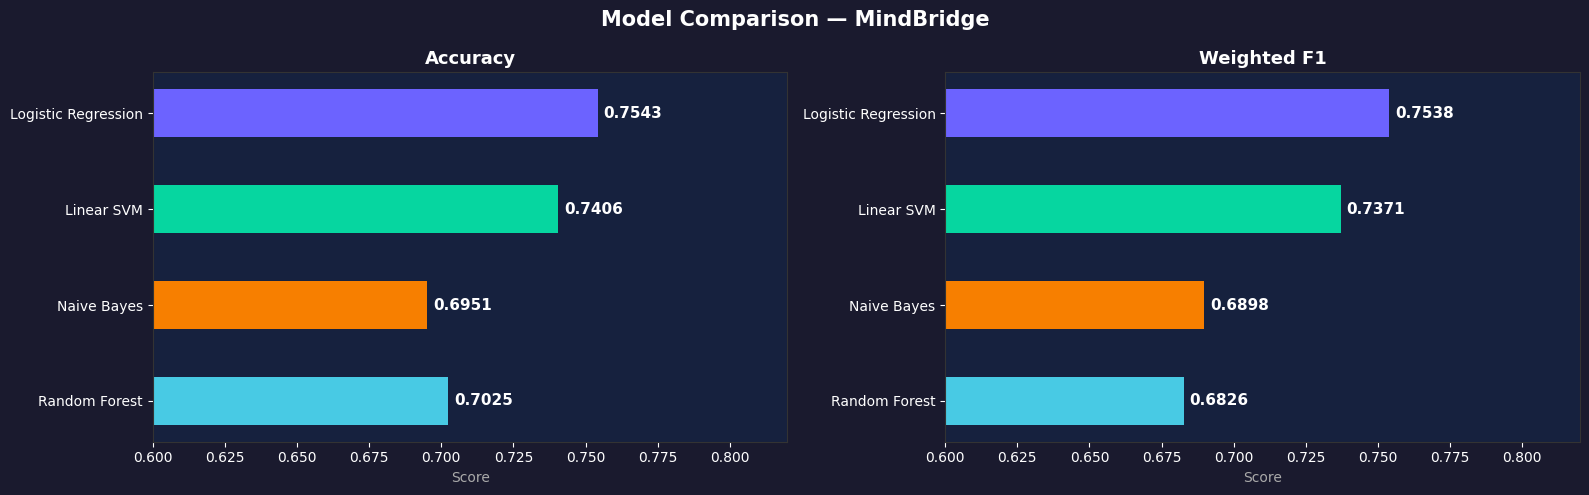

Saved: results/plots/model_comparison.png


In [6]:
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'Weighted F1']
results_df = results_df.sort_values('Weighted F1', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#1a1a2e')
fig.suptitle('Model Comparison — MindBridge', fontsize=15, fontweight='bold', color='white')

colors = ['#48CAE4', '#f77f00', '#06d6a0', '#6C63FF']

for ax, metric in zip(axes, ['Accuracy', 'Weighted F1']):
    ax.set_facecolor('#16213e')
    bars = ax.barh(results_df['Model'], results_df[metric],
                   color=colors, edgecolor='none', height=0.5)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', color='white', fontsize=11, fontweight='bold')
    ax.set_title(metric, color='white', fontsize=13, fontweight='bold')
    ax.set_xlabel('Score', color='#aaa')
    ax.set_xlim(0.6, 0.82)
    ax.tick_params(colors='white')
    for spine in ax.spines.values(): spine.set_color('#333')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_color('white')

plt.tight_layout()
plt.savefig('results/plots/model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: results/plots/model_comparison.png")

## 3. Detailed Classification Report — Best Model

In [7]:
best_model = trained['Logistic Regression']
y_pred_best = best_model.predict(X_test)

print("Classification Report — Logistic Regression")
print("=" * 60)
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Classification Report — Logistic Regression
                      precision    recall  f1-score   support

             Anxiety       0.76      0.83      0.80       544
             Bipolar       0.75      0.78      0.77       375
          Depression       0.76      0.62      0.68      2264
              Normal       0.88      0.91      0.89      2406
Personality disorder       0.54      0.68      0.60       134
              Stress       0.49      0.65      0.56       345
            Suicidal       0.66      0.71      0.68      1596

            accuracy                           0.75      7664
           macro avg       0.69      0.74      0.71      7664
        weighted avg       0.76      0.75      0.75      7664



## 4. Confusion Matrix — Best Model

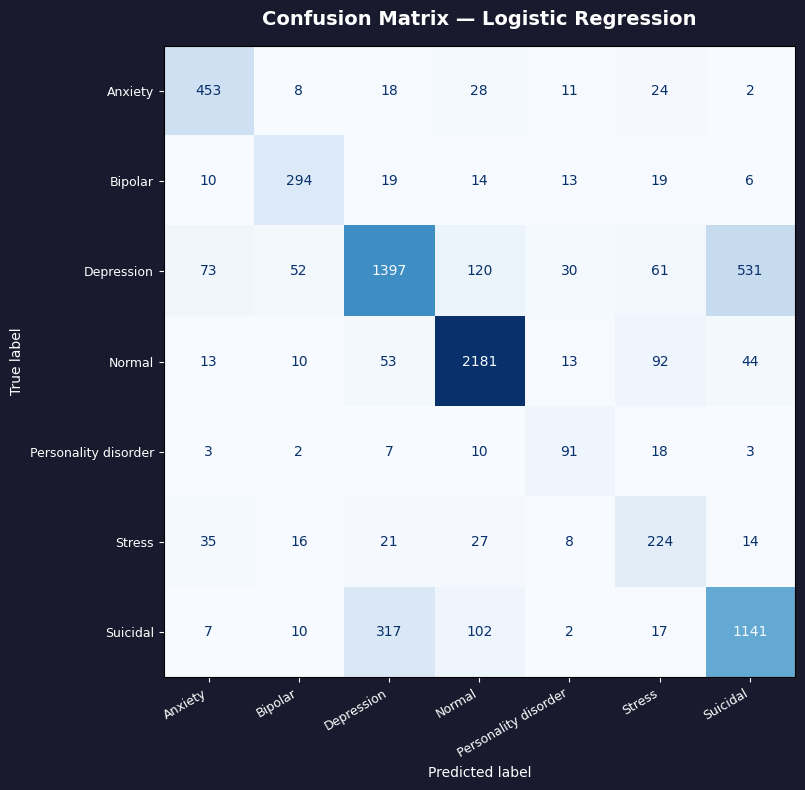

Saved: results/confusion_matrix_logistic_regression.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=le.classes_,
    cmap='Blues',
    ax=ax,
    colorbar=False
)

ax.set_title('Confusion Matrix — Logistic Regression', 
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white', labelsize=9)
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('results/confusion_matrix_logistic_regression.png', 
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print("Saved: results/confusion_matrix_logistic_regression.png")

## 5. Save Best Model

In [9]:
# Save best model
joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(trained['Linear SVM'], 'models/svm_model.pkl')
joblib.dump(trained['Naive Bayes'], 'models/naive_bayes_model.pkl')
joblib.dump(trained['Random Forest'], 'models/random_forest_model.pkl')

print("All models saved to models/")
print("  best_model.pkl          — Logistic Regression")
print("  svm_model.pkl           — Linear SVM")
print("  naive_bayes_model.pkl   — Multinomial Naive Bayes")
print("  random_forest_model.pkl — Random Forest")

All models saved to models/
  best_model.pkl          — Logistic Regression
  svm_model.pkl           — Linear SVM
  naive_bayes_model.pkl   — Multinomial Naive Bayes
  random_forest_model.pkl — Random Forest


## Step 4 Complete — Modeling Summary

| Model | Accuracy | Weighted F1 | Rank |
|-------|----------|-------------|------|
| Logistic Regression | 75.43% | 75.38% | 1st |
| Linear SVM | 74.06% | 73.71% | 2nd |
| Random Forest | 70.25% | 68.26% | 3rd |
| Naive Bayes | 69.51% | 68.98% | 4th |

### Key Findings
- Logistic Regression achieves the best Weighted F1 of 75.38%
- Linear SVM is a close second — both are strong linear classifiers on TF-IDF features
- Random Forest underperforms on sparse high-dimensional TF-IDF vectors
- Naive Bayes is fast but assumes feature independence — weaker on bigrams

### Why Logistic Regression Wins
Linear classifiers dominate because TF-IDF produces sparse high-dimensional 
features where decision boundaries are naturally linear. Tree-based models 
like Random Forest struggle with this sparsity.

### Next Step: 04_Evaluation.ipynb
- Hyperparameter tuning with GridSearchCV
- Ablation studies
- Misclassified examples analysis
- Final model selection